# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex1_multi-reg.ipynb)

In [1]:
import pandas as pd
import sklearn

## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [2]:
df = pd.read_csv("../../../datasets/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df.drop(columns=["mpg"])
y = df["mpg"]

### Step 2.b print the type of each

In [4]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
from pandas.api.types import is_numeric_dtype

if is_numeric_dtype(y):
    target_type = "Numerical"
    ml_task = "Regression"
else:
    target_type = "Categorical"
    ml_task = "Classification"

print(f"Target type: {target_type}")
print(f"Machine Learning Task: {ml_task}")

Target type: Numerical
Machine Learning Task: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (398, 8)
y shape: (398,)


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [7]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
X = df.drop(columns=["mpg"])
y = df["mpg"]

numerical_features = ["displacement", "horsepower", "weight", "acceleration"]
categorical_features = ["cylinders", "model year", "origin", "car name"]

print("Numerical features summary:")
print(X[numerical_features].describe())

print("\nCategorical features summary:")
print(X[categorical_features].astype("object").describe())

Numerical features summary:
       displacement  horsepower       weight  acceleration
count    398.000000  392.000000   398.000000    398.000000
mean     193.425879  104.469388  2970.424623     15.568090
std      104.269838   38.491160   846.841774      2.757689
min       68.000000   46.000000  1613.000000      8.000000
25%      104.250000   75.000000  2223.750000     13.825000
50%      148.500000   93.500000  2803.500000     15.500000
75%      262.000000  126.000000  3608.000000     17.175000
max      455.000000  230.000000  5140.000000     24.800000

Categorical features summary:
        cylinders  model year  origin    car name
count         398         398     398         398
unique          5          13       3         305
top             4          73       1  ford pinto
freq          204          40     249           6


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

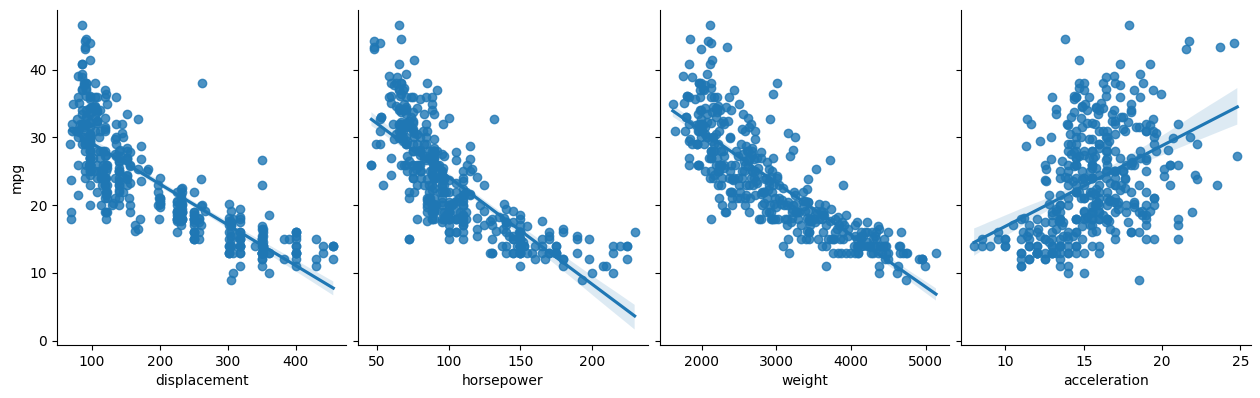

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# numerical features vs target
sns.pairplot(
    df,
    x_vars=numerical_features,
    y_vars="mpg",
    height=4,
    aspect=0.8,
    kind="reg"
)
plt.show()

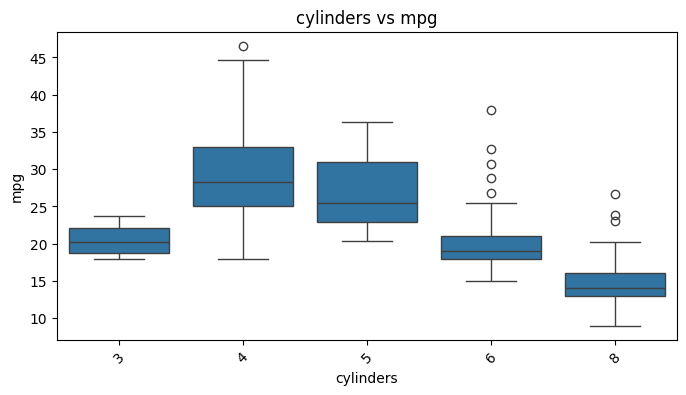

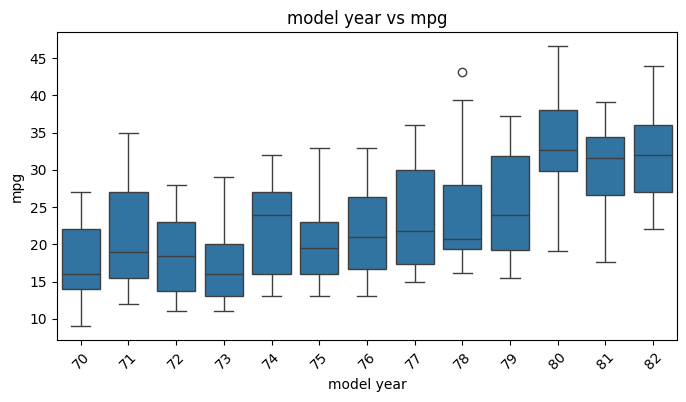

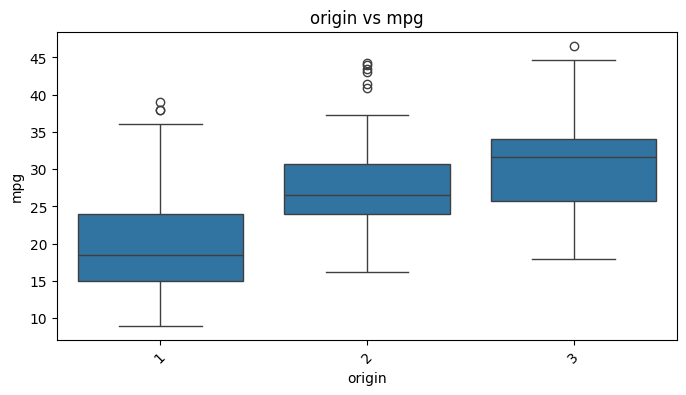

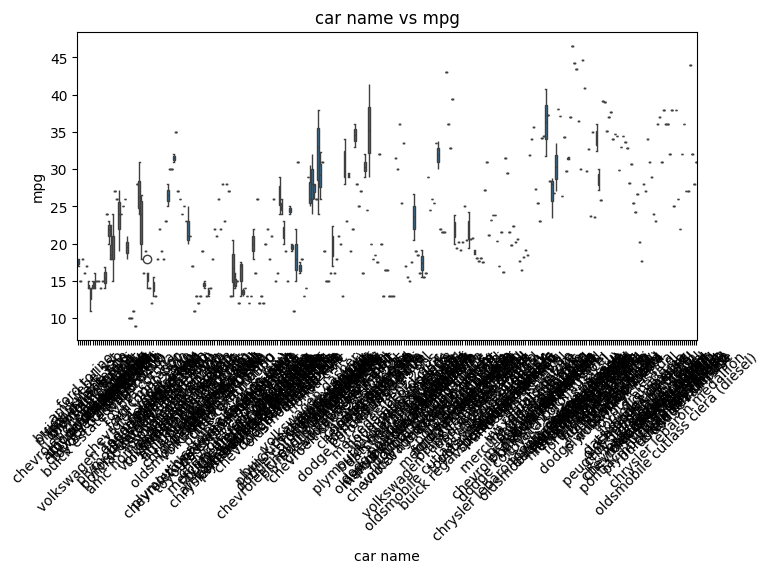

In [10]:
for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col, y="mpg")
    plt.title(f"{col} vs mpg")
    plt.xticks(rotation=45)
    plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

In [11]:
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

features_to_check = ["cylinders", "displacement", "horsepower", "weight", "acceleration"]

for feature in features_to_check:
    correlation_value = df[feature].corr(df["mpg"])
    
    if correlation_value > 0:
        relationship = "Increasing (Positive Correlation)"
    elif correlation_value < 0:
        relationship = "Decreasing (Negative Correlation)"
    else:
        relationship = "None (No Correlation)"
    
    print(f"{feature} vs mpg")
    print(f"Correlation Coefficient: {correlation_value:.2f}")
    print(f"Relationship: {relationship}\n")

cylinders vs mpg
Correlation Coefficient: -0.78
Relationship: Decreasing (Negative Correlation)

displacement vs mpg
Correlation Coefficient: -0.80
Relationship: Decreasing (Negative Correlation)

horsepower vs mpg
Correlation Coefficient: -0.78
Relationship: Decreasing (Negative Correlation)

weight vs mpg
Correlation Coefficient: -0.83
Relationship: Decreasing (Negative Correlation)

acceleration vs mpg
Correlation Coefficient: 0.42
Relationship: Increasing (Positive Correlation)



### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
import pandas as pd

df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

X = df.drop(columns=["mpg"])
y = df["mpg"]

numerical_features = ["displacement", "horsepower", "weight", "acceleration", "model year"]
categorical_features = ["cylinders", "origin", "car name"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

predictor = LinearRegression()

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", predictor)
])

print(pipe)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['displacement', 'horsepower',
                                                   'weight', 'acceleration',
                                                   'model year']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                    

### Step 8. Split the dataset into train and test sets

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 9.a Fit the pipeline on the training set

In [16]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [17]:
import pandas as pd

regressor = pipe.named_steps["regressor"]
feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": regressor.coef_
})

print(coef_df)
print("\nBias term (intercept):", regressor.intercept_)

                                Feature  Coefficient
0                     num__displacement    -1.545270
1                       num__horsepower    -0.469336
2                           num__weight    -3.004454
3                     num__acceleration    -1.123017
4                       num__model year     2.092513
..                                  ...          ...
254          cat__car name_volvo diesel     5.625024
255    cat__car name_vw dasher (diesel)    14.212847
256             cat__car name_vw rabbit     2.783918
257  cat__car name_vw rabbit c (diesel)    13.403807
258      cat__car name_vw rabbit custom    -1.844968

[259 rows x 2 columns]

Bias term (intercept): 22.637721087797946


### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

In [18]:
import numpy as np

numeric_transformer = pipe.named_steps["preprocessor"].named_transformers_["num"]
scaler = numeric_transformer.named_steps["scaler"]

num_features = ["displacement", "horsepower", "weight", "acceleration", "model year"]
weight_idx = num_features.index("weight")

weight_coef_scaled = pipe.named_steps["regressor"].coef_[weight_idx]
weight_coef_original = weight_coef_scaled / scaler.scale_[weight_idx]

kg_100_in_pounds = 220.46
mpg_gain = -kg_100_in_pounds * weight_coef_original

print(f"Weight coefficient in original units (mpg per pound): {weight_coef_original:.6f}")
print(f"Estimated mpg gain if weight decreases by 100 kg: {mpg_gain:.4f}")

Weight coefficient in original units (mpg per pound): -0.003580
Estimated mpg gain if weight decreases by 100 kg: 0.7892


### Step 10. Evaluate the pipeline on the test set

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = pipe.predict(X_test)

print(f"Test R^2 score: {pipe.score(X_test, y_test):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

Test R^2 score: 0.8059
MAE: 2.4371
MSE: 10.4382
